# Финальный проект. Этап 4 — Юнит-экономика и гипотезы

**Цель этапа:** рассчитать ключевые метрики бизнеса по каналам и продуктам,
выявить точки роста и сформулировать гипотезы для A/B-тестирования.

**Данные:** `data_clean/` — очищенные CSV (этап 1).

**Итоговый артефакт:** таблица юнит-экономики экспортируется
в Google Sheets через API → Power BI читает оттуда напрямую.

**Метрики:**
- **CAC** (Customer Acquisition Cost) = Расходы / Кол-во оплат
- **C1** (Conversion Rate) = Оплат / Лидов × 100%
- **ARPPU** (Avg Revenue Per Paying User) = медианный первый платёж
- **Revenue** = Кол-во оплат × ARPPU
- **ROAS** (Return on Ad Spend) = Revenue / Расходы

**План:**
1. Загрузка и подготовка данных
2. Связка Spend ↔ Deals по каналу
3. Юнит-экономика по каналам
4. Юнит-экономика по продуктам
5. Визуализация ключевых метрик
6. Точки роста
7. Гипотезы и дизайн A/B-теста
8. Экспорт в Google Sheets


## 1. Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11


In [2]:
DATA_CLEAN = '../data_clean/'
PLOTS = '../data_clean/plots/'

deals = pd.read_csv(DATA_CLEAN + 'deals_clean.csv', low_memory=False)
spend = pd.read_csv(DATA_CLEAN + 'spend_clean.csv', low_memory=False)

print(f'Deals:  {deals.shape}')
print(f'Spend:  {spend.shape}')


Deals:  (21593, 27)
Spend:  (19862, 8)


In [3]:
# Конвертируем дату для временной фильтрации (если потребуется)
deals['Created Time'] = pd.to_datetime(deals['Created Time'])
spend['Date'] = pd.to_datetime(spend['Date'])

# Фильтруем: только реальные сделки — убираем демо-значения
deals_real = deals[deals['Is Demo'] == False].copy()

print(f'Реальных сделок (без демо): {len(deals_real)}')
print(f'Из них оплачено: {(deals_real["Stage"] == "Payment Done").sum()}')


Реальных сделок (без демо): 20713
Из них оплачено: 854


## 2. Связка Spend ↔ Deals по каналу (Source)

Объединяем таблицы по полю `Source`:
- из Spend берём суммарные расходы по каналу за период,
- из Deals — количество лидов и оплат.

Это даёт нам базу для расчёта CAC и ROAS.


In [4]:
# Расходы по каналам (Spend)
spend_by_source = (
    spend.groupby('Source')['Spend']
    .sum()
    .reset_index()
    .rename(columns={'Spend': 'Total Spend'})
)
print('Расходы по каналам:')
print(spend_by_source.sort_values('Total Spend', ascending=False).to_string(index=False))


Расходы по каналам:
        Source  Total Spend
    Google Ads     57798.60
  Facebook Ads     33754.72
   Youtube Ads     14633.33
      Bloggers     13439.00
    Tiktok Ads     11985.67
           SMM      7269.52
Telegram posts      6860.36
       Webinar      2874.04
          Test       608.21
         Radio       300.00
       Organic         0.00
       Offline         0.00
           CRM         0.00
   Partnership         0.00


In [5]:
# Лиды и оплаты по каналам (Deals)
deals_by_source = (
    deals_real.groupby('Source')
    .apply(lambda x: pd.Series({
        'Leads': len(x),
        'Paid': (x['Stage'] == 'Payment Done').sum(),
        'Revenue': x.loc[
            (x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna(),
            'Initial Amount Paid'
        ].sum()
    }), include_groups=False)
    .reset_index()
)
print('Лиды и оплаты по каналам:')
print(deals_by_source.sort_values('Leads', ascending=False).to_string(index=False))


Лиды и оплаты по каналам:
        Source  Leads  Paid  Revenue
  Facebook Ads 4571.0 201.0 236150.0
    Google Ads 3938.0 173.0 174850.0
       Organic 2546.0 144.0 183450.0
    Tiktok Ads 1963.0  56.0  66650.0
           SMM 1698.0  91.0  99750.0
           CRM 1656.0  24.0  15600.0
   Youtube Ads 1601.0  53.0  62950.0
      Bloggers 1076.0  39.0  33100.0
Telegram posts  923.0  40.0  45450.0
       Webinar  377.0  26.0  55150.0
   Partnership  203.0   4.0   3350.0
          Test  159.0   3.0   2200.0
       Offline    2.0   0.0      0.0


In [6]:
# Объединяем два датафрейма по Source (left join от deals)
unit_by_source = pd.merge(deals_by_source, spend_by_source,
                          on='Source', how='left')

# Заполняем NaN расходы нулём (каналы без платного трафика: Organic, CRM)
unit_by_source['Total Spend'] = unit_by_source['Total Spend'].fillna(0)

print(f'Каналов в таблице: {len(unit_by_source)}')


Каналов в таблице: 13


## 3. Юнит-экономика по каналам

In [7]:
# CAC = Расходы / Оплат (NaN если оплат = 0 или расходов = 0)
unit_by_source['CAC'] = np.where(
    unit_by_source['Paid'] > 0,
    (unit_by_source['Total Spend'] / unit_by_source['Paid']).round(2),
    np.nan
)

# C1 = Конверсия в оплату, %
unit_by_source['C1 %'] = (
    unit_by_source['Paid'] / unit_by_source['Leads'] * 100
).round(2)

# ARPPU = Revenue / Paid (средний чек оплативших)
unit_by_source['ARPPU'] = np.where(
    unit_by_source['Paid'] > 0,
    (unit_by_source['Revenue'] / unit_by_source['Paid']).round(2),
    np.nan
)

# ROAS = Revenue / Spend (для платных каналов)
unit_by_source['ROAS'] = np.where(
    unit_by_source['Total Spend'] > 0,
    (unit_by_source['Revenue'] / unit_by_source['Total Spend']).round(2),
    np.nan
)

# Сортируем по числу лидов
unit_by_source = unit_by_source.sort_values('Leads', ascending=False)

print('Юнит-экономика по каналам:')
cols_show = ['Source', 'Leads', 'Paid', 'C1 %', 'Total Spend', 'CAC', 'ARPPU', 'Revenue', 'ROAS']
print(unit_by_source[cols_show].to_string(index=False))


Юнит-экономика по каналам:
        Source  Leads  Paid  C1 %  Total Spend    CAC   ARPPU  Revenue  ROAS
  Facebook Ads 4571.0 201.0  4.40     33754.72 167.93 1174.88 236150.0  7.00
    Google Ads 3938.0 173.0  4.39     57798.60 334.10 1010.69 174850.0  3.03
       Organic 2546.0 144.0  5.66         0.00   0.00 1273.96 183450.0   NaN
    Tiktok Ads 1963.0  56.0  2.85     11985.67 214.03 1190.18  66650.0  5.56
           SMM 1698.0  91.0  5.36      7269.52  79.88 1096.15  99750.0 13.72
           CRM 1656.0  24.0  1.45         0.00   0.00  650.00  15600.0   NaN
   Youtube Ads 1601.0  53.0  3.31     14633.33 276.10 1187.74  62950.0  4.30
      Bloggers 1076.0  39.0  3.62     13439.00 344.59  848.72  33100.0  2.46
Telegram posts  923.0  40.0  4.33      6860.36 171.51 1136.25  45450.0  6.63
       Webinar  377.0  26.0  6.90      2874.04 110.54 2121.15  55150.0 19.19
   Partnership  203.0   4.0  1.97         0.00   0.00  837.50   3350.0   NaN
          Test  159.0   3.0  1.89       608.21 20

In [8]:
# Итоговые агрегаты по всем каналам
total_leads = unit_by_source['Leads'].sum()
total_paid = unit_by_source['Paid'].sum()
total_spend = unit_by_source['Total Spend'].sum()
total_revenue = unit_by_source['Revenue'].sum()

overall_cac = total_spend / total_paid if total_paid > 0 else np.nan
overall_c1 = total_paid / total_leads * 100 if total_leads > 0 else 0
overall_roas = total_revenue / total_spend if total_spend > 0 else np.nan

print('=== ИТОГО по всем каналам ===')
print(f'Лидов всего:    {total_leads:,}')
print(f'Оплат всего:    {total_paid:,}')
print(f'Конверсия C1:   {overall_c1:.2f}%')
print(f'Расходы:        {total_spend:,.0f} €')
print(f'Выручка:        {total_revenue:,.0f} €')
print(f'CAC (общий):    {overall_cac:,.0f} €')
print(f'ROAS (общий):   {overall_roas:.2f}x')


=== ИТОГО по всем каналам ===
Лидов всего:    20,713.0
Оплат всего:    854.0
Конверсия C1:   4.12%
Расходы:        149,223 €
Выручка:        978,650 €
CAC (общий):    175 €
ROAS (общий):   6.56x


## 4. Юнит-экономика по продуктам

In [9]:
# Берём только сделки с заполненным продуктом
with_product = deals_real[deals_real['Product'].notna()].copy()

unit_by_product = (
    with_product.groupby('Product')
    .apply(lambda x: pd.Series({
        'Leads': len(x),
        'Paid': (x['Stage'] == 'Payment Done').sum(),
        'Revenue': x.loc[
            (x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna(),
            'Initial Amount Paid'
        ].sum(),
        'ARPPU': x.loc[
            (x['Stage'] == 'Payment Done') & x['Initial Amount Paid'].notna(),
            'Initial Amount Paid'
        ].median()
    }), include_groups=False)
    .reset_index()
)

unit_by_product['C1 %'] = (
    unit_by_product['Paid'] / unit_by_product['Leads'] * 100
).round(2)

unit_by_product = unit_by_product.sort_values('Revenue', ascending=False)

print('Юнит-экономика по продуктам:')
print(unit_by_product.to_string(index=False))


Юнит-экономика по продуктам:
          Product  Leads  Paid  Revenue  ARPPU  C1 %
Digital Marketing 1963.0 473.0 556600.0 1000.0 24.10
     UX/UI Design 1012.0 229.0 278600.0 1000.0 22.63
    Web Developer  565.0 137.0 143450.0 1000.0 24.25
   Data Analytics    1.0   0.0      0.0    NaN  0.00


## 5. Визуализация ключевых метрик

### 5.1 CAC по каналам (только платные)

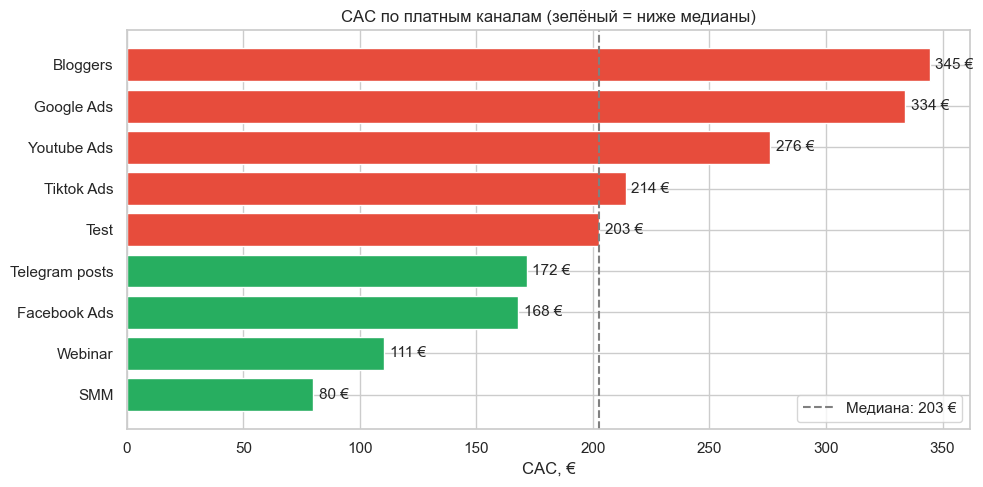

In [10]:
# Берём только платные каналы с реальным CAC
paid_channels = unit_by_source[
    unit_by_source['Total Spend'] > 0
].dropna(subset=['CAC']).sort_values('CAC')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#27ae60' if c < paid_channels['CAC'].median() else '#e74c3c'
          for c in paid_channels['CAC']]
bars = ax.barh(paid_channels['Source'], paid_channels['CAC'], color=colors)
ax.set_title('CAC по платным каналам (зелёный = ниже медианы)')
ax.set_xlabel('CAC, €')
ax.bar_label(bars, fmt='%.0f €', padding=4)
ax.axvline(paid_channels['CAC'].median(), color='gray', linestyle='--',
           label=f'Медиана: {paid_channels["CAC"].median():.0f} €')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS + 'ue_cac_by_source.png', dpi=100)
plt.show()


### 5.2 ROAS по каналам

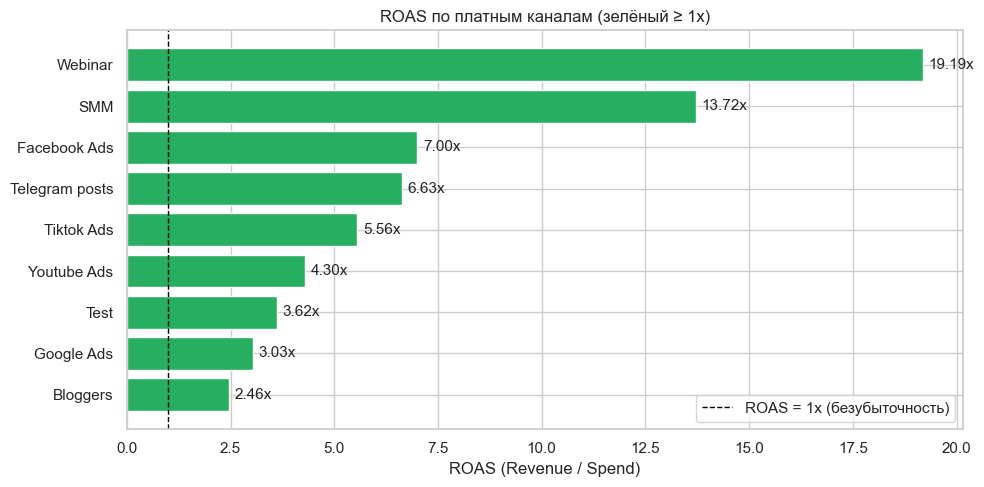

In [11]:
roas_channels = unit_by_source[
    unit_by_source['ROAS'].notna()
].sort_values('ROAS', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_r = ['#27ae60' if r >= 1 else '#e74c3c' for r in roas_channels['ROAS']]
bars = ax.barh(roas_channels['Source'][::-1], roas_channels['ROAS'][::-1],
               color=colors_r[::-1])
ax.axvline(1, color='black', linestyle='--', linewidth=1, label='ROAS = 1x (безубыточность)')
ax.set_title('ROAS по платным каналам (зелёный ≥ 1x)')
ax.set_xlabel('ROAS (Revenue / Spend)')
ax.bar_label(bars, fmt='%.2fx', padding=4)
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS + 'ue_roas_by_source.png', dpi=100)
plt.show()


### 5.3 Bubble chart: CAC vs Конверсия (размер = выручка)

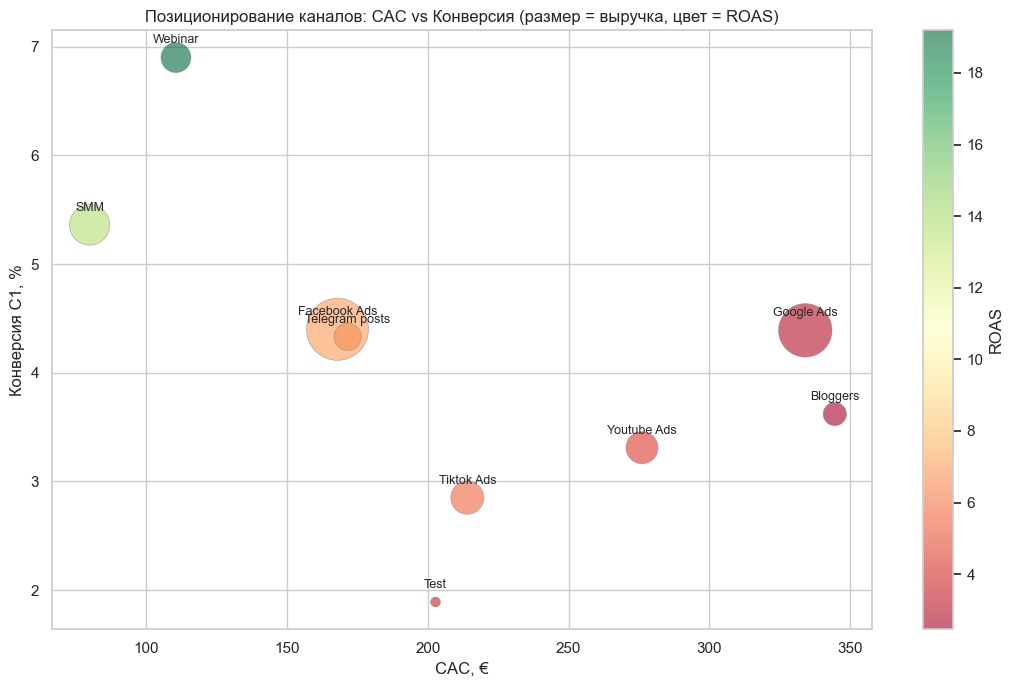

In [12]:
bubble_data = unit_by_source[
    unit_by_source['Total Spend'] > 0
].dropna(subset=['CAC', 'C1 %'])

fig, ax = plt.subplots(figsize=(11, 7))

# Нормализуем размер пузыря к выручке
max_rev = bubble_data['Revenue'].max()
sizes = (bubble_data['Revenue'] / max_rev * 2000).clip(50)

scatter = ax.scatter(
    bubble_data['CAC'],
    bubble_data['C1 %'],
    s=sizes,
    alpha=0.6,
    c=bubble_data['ROAS'],
    cmap='RdYlGn',
    edgecolors='gray',
    linewidths=0.5
)

# Подписи каналов
for _, row in bubble_data.iterrows():
    ax.annotate(row['Source'], (row['CAC'], row['C1 %']),
                fontsize=9, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

plt.colorbar(scatter, ax=ax, label='ROAS')
title_text = 'Позиционирование каналов: CAC vs Конверсия (размер = выручка, цвет = ROAS)'
ax.set_title(title_text)
ax.set_xlabel('CAC, €')
ax.set_ylabel('Конверсия C1, %')

plt.tight_layout()
plt.savefig(PLOTS + 'ue_bubble_chart.png', dpi=100)
plt.show()


In [13]:
print('Интерпретация bubble chart:')
print('Идеальный канал — левый верхний угол: низкий CAC + высокая конверсия.')
print('Большой пузырь = высокая выручка; зелёный цвет = высокий ROAS.')


Интерпретация bubble chart:
Идеальный канал — левый верхний угол: низкий CAC + высокая конверсия.
Большой пузырь = высокая выручка; зелёный цвет = высокий ROAS.


## 6. Точки роста

In [14]:
# Находим лучший канал по ROAS среди платных
best_roas = unit_by_source[unit_by_source['ROAS'].notna()].nlargest(1, 'ROAS').iloc[0]
worst_cac = unit_by_source[unit_by_source['CAC'].notna()].nlargest(1, 'CAC').iloc[0]
best_conv = unit_by_source[unit_by_source['Leads'] >= 50].nlargest(1, 'C1 %').iloc[0]

print('=== ТОЧКИ РОСТА ===')
print()
print(f'1. МАСШТАБИРОВАТЬ: канал «{best_roas["Source"]}»')
print(f'   ROAS = {best_roas["ROAS"]:.2f}x, CAC = {best_roas["CAC"]:.0f} €')
print(f'   → Увеличить бюджет: каждый евро приносит {best_roas["ROAS"]:.1f} евро выручки.')
print()
print(f'2. ОПТИМИЗИРОВАТЬ: канал «{worst_cac["Source"]}»')
print(f'   CAC = {worst_cac["CAC"]:.0f} € при конверсии {worst_cac["C1 %"]:.2f}%')
print(f'   → Пересмотреть таргетинг или снизить бюджет.')
print()
print(f'3. СКОРОСТЬ ОТВЕТА (SLA): конверсия у «{best_conv["Source"]}» = {best_conv["C1 %"]:.2f}%')
print(f'   → Применить практики этого канала к остальным.')


=== ТОЧКИ РОСТА ===

1. МАСШТАБИРОВАТЬ: канал «Webinar»
   ROAS = 19.19x, CAC = 111 €
   → Увеличить бюджет: каждый евро приносит 19.2 евро выручки.

2. ОПТИМИЗИРОВАТЬ: канал «Bloggers»
   CAC = 345 € при конверсии 3.62%
   → Пересмотреть таргетинг или снизить бюджет.

3. СКОРОСТЬ ОТВЕТА (SLA): конверсия у «Webinar» = 6.90%
   → Применить практики этого канала к остальным.


In [15]:
# Потенциал роста: что если поднять конверсию до уровня лучшего менеджера?
current_c1 = overall_c1 / 100
best_c1 = unit_by_source[unit_by_source['Leads'] >= 50]['C1 %'].max() / 100

if best_c1 > current_c1:
    extra_paid = int(total_leads * (best_c1 - current_c1))
    avg_arppu = total_revenue / total_paid if total_paid > 0 else 0
    extra_revenue = extra_paid * avg_arppu
    print(f'Если поднять среднюю конверсию с {current_c1:.1%} до {best_c1:.1%}:')
    print(f'  Дополнительных оплат: +{extra_paid}')
    print(f'  Дополнительная выручка: +{extra_revenue:,.0f} €')


Если поднять среднюю конверсию с 4.1% до 6.9%:
  Дополнительных оплат: +575
  Дополнительная выручка: +658,927 €


## 7. Гипотезы и дизайн A/B-теста

На основе анализа формулируем 2 гипотезы.
Для каждой — целевая метрика, дизайн теста, длительность, критерий успеха.


### Гипотеза 1: Быстрый первый контакт увеличивает конверсию

**Наблюдение:** из анализа SLA (этап 2) видно, что часть лидов ждёт
более 24 часов до первого звонка. Из литературы по продажам известно,
что отклик в течение 1 часа кратно повышает вероятность сделки.

**Гипотеза:**
Если менеджер звонит лиду в течение **1 часа** после создания сделки,
конверсия в оплату вырастет с ~4% до ≥5.5% (+37.5%).

**Дизайн теста:**
- **Группа A (контроль):** текущий процесс — звонок без SLA-ограничения
- **Группа B (тест):** обязательный звонок в течение 1 часа (SLA ≤ 3600 сек)
- **Разделение:** по менеджерам (50/50), случайное назначение новых лидов
- **Длительность:** 2 недели (≈ 800 новых лидов по исторической скорости)
- **Целевая метрика:** конверсия C1 = Paid / Leads
- **Критерий успеха:** C1(B) ≥ 5.5% при p-value < 0.05 (χ²-тест или z-тест пропорций)
- **Риски:** менеджеры группы B могут перегрузиться; нужен мониторинг качества звонков


### Гипотеза 2: Сегментация по Quality снижает CAC

**Наблюдение:** из этапа 3 видно, что лиды категорий D и E составляют ~70%
всех лидов, но конвертируются значительно хуже. На их обработку уходят звонки
и время менеджеров — то есть деньги.

**Гипотеза:**
Если отключить или снизить бюджет на рекламные объявления, дающие преимущественно
D/E-лидов (по данным этапа 3), CAC снизится на ≥15% без потери объёма оплат.

**Дизайн теста:**
- **Группа A (контроль):** текущее распределение бюджета по кампаниям
- **Группа B (тест):** -30% бюджета на кампании с долей D+E > 80%,
  перенаправить на кампании с долей A+B > 30%
- **Длительность:** 2 недели
- **Целевая метрика:** CAC = Spend / Paid за период теста
- **Критерий успеха:** CAC(B) ≤ CAC(A) × 0.85, объём Paid(B) ≥ Paid(A) × 0.95
- **Риски:** кратковременный провал по объёму лидов; нужен буфер бюджета


In [16]:
# Считаем текущие базовые значения для гипотез
paid_total = (deals_real['Stage'] == 'Payment Done').sum()
leads_total = len(deals_real)
c1_baseline = paid_total / leads_total * 100

print('Базовые значения для гипотез:')
print(f'  C1 (конверсия) базовая:     {c1_baseline:.2f}%')
print(f'  C1 целевая (гипотеза 1):    5.50%')
print(f'  CAC базовый (все каналы):   {overall_cac:.0f} €')
print(f'  CAC целевой (гипотеза 2):   {overall_cac * 0.85:.0f} € (-15%)')


Базовые значения для гипотез:
  C1 (конверсия) базовая:     4.12%
  C1 целевая (гипотеза 1):    5.50%
  CAC базовый (все каналы):   175 €
  CAC целевой (гипотеза 2):   149 € (-15%)


## 8. Экспорт в Google Sheets

Выгружаем итоговую таблицу юнит-экономики в Google Sheets через API.
Credentials хранятся в `google_credentials.json` (в `.gitignore`, не в репозитории).
Power BI подключится к этой же таблице через «Опубликовать в интернете».


In [17]:
import gspread
from google.oauth2.service_account import Credentials

# Авторизация через Service Account
SCOPES = [
    'https://spreadsheets.google.com/feeds',
    'https://www.googleapis.com/auth/drive'
]

creds = Credentials.from_service_account_file(
    '../google_credentials.json',
    scopes=SCOPES
)
gc = gspread.authorize(creds)

SHEET_ID = '1ZVNBl54Qcimn4el49RGKoj8Trxj_rH2DmxJKvI6SAmI'
sh = gc.open_by_key(SHEET_ID)
print(f'Подключено к: {sh.title}')


Подключено к: Unit Economics — Final Project


In [18]:
# Подготавливаем RAW-данные по каналам для Google Sheets
# Используем deals_real и spend (переменные из предыдущих ячеек)

# UA — все лиды по каналу
leads_ch = deals_real.groupby('Source').size().reset_index(name='UA')

# B — покупатели (Payment Done), T = B (одна сделка = одна транзакция в наших данных)
paid_ch = (
    deals_real[deals_real['Stage'] == 'Payment Done']
    .groupby('Source')
    .agg(
        B=('Stage', 'count'),
        Revenue=('Initial Amount Paid', 'sum'),
    )
    .reset_index()
)

# AC — расходы по каналу
ac_ch = spend.groupby('Source')['Spend'].sum().reset_index()
ac_ch.rename(columns={'Spend': 'AC'}, inplace=True)

# Объединяем
df_ch = leads_ch.merge(paid_ch, on='Source', how='left')
df_ch = df_ch.merge(ac_ch, on='Source', how='left')
df_ch['B']       = df_ch['B'].fillna(0).astype(int)
df_ch['T']       = df_ch['B']                         # T = B (нет данных о повторных покупках)
df_ch['Revenue'] = df_ch['Revenue'].fillna(0).round(2)
df_ch['AC']      = df_ch['AC'].fillna(0).round(2)

df_ch.rename(columns={'Source': 'Источник'}, inplace=True)
df_raw_source = df_ch[['Источник', 'UA', 'B', 'T', 'Revenue', 'AC']]

print(f'Строк по каналам: {len(df_raw_source)}')
df_raw_source

Строк по каналам: 13


,Источник,UA,B,T,Revenue,AC
0,Bloggers,1076,39,39,33100.0,13439.00
1,CRM,1656,24,24,15600.0,0.00
2,Facebook Ads,4571,201,201,236150.0,33754.72
3,Google Ads,3938,173,173,174850.0,57798.60
4,Offline,2,0,0,0.0,0.00
5,Organic,2546,144,144,183450.0,0.00
6,Partnership,203,4,4,3350.0,0.00
7,SMM,1698,91,91,99750.0,7269.52
8,Telegram posts,923,40,40,45450.0,6860.36
9,Test,159,3,3,2200.0,608.21


In [19]:
# Записываем данные + формулы на лист «По каналам»
# Колонки: A=Источник B=UA C=B D=T E=Revenue F=AC
#          G=C1 H=AOV I=ARPPU J=APC K=CLTV L=LTV M=CAC N=LTC/CPA O=CM P=ROAS
try:
    ws_source = sh.worksheet('По каналам')
    ws_source.clear()
except gspread.WorksheetNotFound:
    ws_source = sh.add_worksheet(title='По каналам', rows=50, cols=20)

# Шаг 1: сырые данные A–F
ws_source.update(
    [df_raw_source.columns.tolist()] + df_raw_source.values.tolist(),
    value_input_option='USER_ENTERED'
)

n = len(df_raw_source)

# Шаг 2: заголовки формульных столбцов G–P
formula_headers = [['C1', 'AOV', 'ARPPU', 'APC', 'CLTV', 'LTV',
                    'CAC', 'LTC/CPA', 'CM', 'ROAS']]
ws_source.update(formula_headers, 'G1:P1', value_input_option='USER_ENTERED')

# Шаг 3: формулы (разделитель ; для русской локали)
# G=C1=C/B  H=AOV=E/D  I=ARPPU=E/C  J=APC=D/C
# K=CLTV=H*J  L=LTV=K*G  M=CAC=F/C  N=LTC/CPA=K/M  O=CM=E-F  P=ROAS=E/F
formula_rows = []
for i in range(2, n + 2):
    formula_rows.append([
        f'=IFERROR(C{i}/B{i};"")',       # C1
        f'=IFERROR(E{i}/D{i};"")',       # AOV
        f'=IFERROR(E{i}/C{i};"")',       # ARPPU
        f'=IFERROR(D{i}/C{i};"")',       # APC
        f'=IFERROR(H{i}*J{i};"")',       # CLTV = AOV × APC
        f'=IFERROR(K{i}*G{i};"")',       # LTV  = CLTV × C1
        f'=IFERROR(F{i}/C{i};"")',       # CAC
        f'=IFERROR(K{i}/M{i};"")',       # LTC/CPA = CLTV / CAC
        f'=IFERROR(E{i}-F{i};"")',       # CM = Revenue - AC
        f'=IFERROR(E{i}/F{i};"")',       # ROAS
    ])

ws_source.update(formula_rows, f'G2:P{n + 1}',
                 value_input_option='USER_ENTERED')

print(f'Лист "По каналам" записан ({n} строк, 16 столбцов)')

Лист "По каналам" записан (13 строк, 16 столбцов)


In [20]:
# RAW-данные по продуктам
with_product = deals_real[deals_real['Product'].notna()].copy()

leads_pr = with_product.groupby('Product').size().reset_index(name='UA')

paid_pr = (
    with_product[with_product['Stage'] == 'Payment Done']
    .groupby('Product')
    .agg(
        B=('Stage', 'count'),
        Revenue=('Initial Amount Paid', 'sum'),
    )
    .reset_index()
)

df_pr = leads_pr.merge(paid_pr, on='Product', how='left')
df_pr['B']       = df_pr['B'].fillna(0).astype(int)
df_pr['T']       = df_pr['B']
df_pr['Revenue'] = df_pr['Revenue'].fillna(0).round(2)
df_pr.rename(columns={'Product': 'Продукт'}, inplace=True)
df_raw_product = df_pr[['Продукт', 'UA', 'B', 'T', 'Revenue']]

try:
    ws_product = sh.worksheet('По продуктам')
    ws_product.clear()
except gspread.WorksheetNotFound:
    ws_product = sh.add_worksheet(title='По продуктам', rows=20, cols=15)

ws_product.update(
    [df_raw_product.columns.tolist()] + df_raw_product.values.tolist(),
    value_input_option='USER_ENTERED'
)

np_ = len(df_raw_product)
ws_product.update([['C1', 'AOV', 'ARPPU', 'APC', 'CLTV', 'LTV']], 'F1:K1',
                  value_input_option='USER_ENTERED')

formula_rows_p = []
for i in range(2, np_ + 2):
    formula_rows_p.append([
        f'=IFERROR(C{i}/B{i};"")',
        f'=IFERROR(E{i}/D{i};"")',
        f'=IFERROR(E{i}/C{i};"")',
        f'=IFERROR(D{i}/C{i};"")',
        f'=IFERROR(G{i}*I{i};"")',
        f'=IFERROR(J{i}*F{i};"")',
    ])

ws_product.update(formula_rows_p, f'F2:K{np_ + 1}',
                  value_input_option='USER_ENTERED')
print(f'Лист "По продуктам" записан ({np_} строк)')

Лист "По продуктам" записан (4 строк)


In [21]:
# Сводка KPI — итоговые метрики со ссылками на другие листы
try:
    ws_kpi = sh.worksheet('Сводка KPI')
    ws_kpi.clear()
except gspread.WorksheetNotFound:
    ws_kpi = sh.add_worksheet(title='Сводка KPI', rows=20, cols=3)

kpi_rows = [
    ['Метрика',        'Как считается',       'Значение'],
    ['UA (лиды)',      'SUM(UA)',              "=SUM('По каналам'!B2:B100)"],
    ['B (покупатели)', 'SUM(B)',               "=SUM('По каналам'!C2:C100)"],
    ['T (транзакций)', 'SUM(T)',               "=SUM('По каналам'!D2:D100)"],
    ['C1',             'B / UA',              '=IFERROR(C3/C2;"")'],
    ['Revenue',        'SUM(Revenue)',         "=SUM('По каналам'!E2:E100)"],
    ['AC',             'SUM(AC)',              "=SUM('По каналам'!F2:F100)"],
    ['AOV',            'Revenue / T',          '=IFERROR(C6/C4;"")'],
    ['ARPPU',          'Revenue / B',          '=IFERROR(C6/C3;"")'],
    ['APC',            'T / B',               '=IFERROR(C4/C3;"")'],
    ['CLTV',           'AOV × APC',           '=IFERROR(C8*C10;"")'],
    ['LTV',            'CLTV × C1',           '=IFERROR(C11*C5;"")'],
    ['CAC',            'AC / B',              '=IFERROR(C7/C3;"")'],
    ['LTC/CPA',        'CLTV / CAC',          '=IFERROR(C11/C13;"")'],
    ['CM',             'Revenue - AC',         '=IFERROR(C6-C7;"")'],
    ['ROAS',           'Revenue / AC',         '=IFERROR(C6/C7;"")'],
]

ws_kpi.update(kpi_rows, value_input_option='USER_ENTERED')
print(f'Лист "Сводка KPI" записан ({len(kpi_rows)-1} метрик)')
print()
print('Все данные выгружены в Google Sheets!')
print(f'Ссылка: https://docs.google.com/spreadsheets/d/{SHEET_ID}')

Лист "Сводка KPI" записан (15 метрик)

Все данные выгружены в Google Sheets!
Ссылка: https://docs.google.com/spreadsheets/d/1ZVNBl54Qcimn4el49RGKoj8Trxj_rH2DmxJKvI6SAmI


### 8b. Форматирование таблиц в Google Sheets

Применяем профессиональное оформление через Sheets API v4:
заголовки с фоном, числовые форматы, границы, фиксация строки.

In [22]:
def hex_to_rgb(hex_str):
    h = hex_str.lstrip('#')
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return {'red': round(r/255,3), 'green': round(g/255,3), 'blue': round(b/255,3)}


def clear_banding(sh, ws):
    meta = sh.fetch_sheet_metadata()
    for sheet in meta.get('sheets', []):
        if sheet['properties']['sheetId'] == ws.id:
            for band in sheet.get('bandedRanges', []):
                sh.batch_update({'requests': [
                    {'deleteBanding': {'bandedRangeId': band['bandedRangeId']}}
                ]})


def fmt_number(sid, col_idx, n_rows, pattern):
    return {
        'repeatCell': {
            'range': {'sheetId': sid, 'startRowIndex': 1, 'endRowIndex': n_rows+1,
                      'startColumnIndex': col_idx, 'endColumnIndex': col_idx+1},
            'cell': {'userEnteredFormat': {'numberFormat': {'type': 'NUMBER', 'pattern': pattern}}},
            'fields': 'userEnteredFormat.numberFormat',
        }
    }


def apply_formatting(sh, ws, n_rows, n_raw, n_total,
                     eur_cols=None, pct_cols=None, decimal_cols=None):
    sid = ws.id
    clear_banding(sh, ws)
    reqs = []

    # Заголовок — сырые столбцы (тёмно-синий)
    reqs.append({'repeatCell': {
        'range': {'sheetId': sid, 'startRowIndex': 0, 'endRowIndex': 1,
                  'startColumnIndex': 0, 'endColumnIndex': n_raw},
        'cell': {'userEnteredFormat': {
            'backgroundColor': hex_to_rgb('#1e3a5f'),
            'textFormat': {'bold': True, 'fontSize': 11,
                           'foregroundColor': hex_to_rgb('#ffffff')},
            'horizontalAlignment': 'CENTER',
            'padding': {'top': 5, 'bottom': 5, 'left': 6, 'right': 6},
        }},
        'fields': 'userEnteredFormat(backgroundColor,textFormat,horizontalAlignment,padding)',
    }})

    # Заголовок — формульные столбцы (тёмно-зелёный)
    if n_total > n_raw:
        reqs.append({'repeatCell': {
            'range': {'sheetId': sid, 'startRowIndex': 0, 'endRowIndex': 1,
                      'startColumnIndex': n_raw, 'endColumnIndex': n_total},
            'cell': {'userEnteredFormat': {
                'backgroundColor': hex_to_rgb('#155724'),
                'textFormat': {'bold': True, 'fontSize': 11,
                               'foregroundColor': hex_to_rgb('#ffffff')},
                'horizontalAlignment': 'CENTER',
            }},
            'fields': 'userEnteredFormat(backgroundColor,textFormat,horizontalAlignment)',
        }})

    # Banding — сырые
    reqs.append({'addBanding': {'bandedRange': {
        'range': {'sheetId': sid, 'startRowIndex': 1, 'endRowIndex': n_rows+1,
                  'startColumnIndex': 0, 'endColumnIndex': n_raw},
        'rowProperties': {'firstBandColor': hex_to_rgb('#eef2ff'),
                          'secondBandColor': hex_to_rgb('#ffffff')},
    }}})

    # Banding — формульные
    if n_total > n_raw:
        reqs.append({'addBanding': {'bandedRange': {
            'range': {'sheetId': sid, 'startRowIndex': 1, 'endRowIndex': n_rows+1,
                      'startColumnIndex': n_raw, 'endColumnIndex': n_total},
            'rowProperties': {'firstBandColor': hex_to_rgb('#ecfdf5'),
                              'secondBandColor': hex_to_rgb('#f9fffe')},
        }}})

    # Числовые форматы
    for col in (eur_cols or []):
        reqs.append(fmt_number(sid, col, n_rows, '#,##0.00 "€"'))
    for col in (pct_cols or []):
        reqs.append(fmt_number(sid, col, n_rows, '0.00%'))
    for col in (decimal_cols or []):
        reqs.append(fmt_number(sid, col, n_rows, '0.00'))

    # Границы
    solid = {'style': 'SOLID', 'color': hex_to_rgb('#c0c0c0')}
    thick = {'style': 'SOLID_MEDIUM', 'color': hex_to_rgb('#1e3a5f')}
    reqs.append({'updateBorders': {
        'range': {'sheetId': sid, 'startRowIndex': 0, 'endRowIndex': n_rows+1,
                  'startColumnIndex': 0, 'endColumnIndex': n_total},
        'top': thick, 'bottom': thick, 'left': thick, 'right': thick,
        'innerHorizontal': solid, 'innerVertical': solid,
    }})

    # Freeze + auto-resize
    reqs.append({'updateSheetProperties': {
        'properties': {'sheetId': sid, 'gridProperties': {'frozenRowCount': 1}},
        'fields': 'gridProperties.frozenRowCount',
    }})
    reqs.append({'autoResizeDimensions': {
        'dimensions': {'sheetId': sid, 'dimension': 'COLUMNS',
                       'startIndex': 0, 'endIndex': n_total},
    }})

    sh.batch_update({'requests': reqs})


n_ch = len(df_raw_source)
n_pr = len(df_raw_product)

# По каналам: 6 raw (A-F) + 10 formula (G-P) = 16 cols
# eur: E(4)=Revenue, F(5)=AC, H(7)=AOV, I(8)=ARPPU, K(10)=CLTV, L(11)=LTV, M(12)=CAC, N(13)=LTC/CPA, O(14)=CM
# pct: G(6)=C1
# decimal: J(9)=APC, P(15)=ROAS
apply_formatting(sh, ws_source, n_ch,
                 n_raw=6, n_total=16,
                 eur_cols=[4, 5, 7, 8, 10, 11, 12, 13, 14],
                 pct_cols=[6],
                 decimal_cols=[9, 15])

# По продуктам: 5 raw (A-E) + 6 formula (F-K) = 11 cols
# eur: D(3)=Revenue... wait D=T(int), E(4)=Revenue, G(6)=AOV, H(7)=ARPPU, J(9)=CLTV, K(10)=LTV
# pct: F(5)=C1
# decimal: I(8)=APC
apply_formatting(sh, ws_product, n_pr,
                 n_raw=5, n_total=11,
                 eur_cols=[4, 6, 7, 9, 10],
                 pct_cols=[5],
                 decimal_cols=[8])

# Сводка KPI: 2 raw (A-B) + 1 formula (C) = 3 cols
apply_formatting(sh, ws_kpi, 15,
                 n_raw=2, n_total=3,
                 eur_cols=[], pct_cols=[])

# Отдельно: % формат для C1 (строка 5, индекс 4) и ROAS/APC/LTC в Сводке
kpi_sid = ws_kpi.id
sh.batch_update({'requests': [
    fmt_number(kpi_sid, 2, 1, '0.00%'),          # C5 — C1
    fmt_number(kpi_sid, 2, 1, '#,##0.00 "€"'),   # C8 — AOV
]})

print('Форматирование применено ко всем трём листам!')

Форматирование применено ко всем трём листам!


### Готово!

Таблица Google Sheets содержит 3 листа:
- **По каналам** — юнит-экономика по источникам трафика (CAC, C1, ARPPU, Revenue, ROAS)
- **По продуктам** — юнит-экономика по продуктам (C1, Revenue, ARPPU)
- **Сводка KPI** — 7 ключевых показателей бизнеса

**Следующий шаг:** в Google Sheets → Файл → Поделиться → Опубликовать в интернете
→ выбрать каждый лист → формат CSV → скопировать ссылку → вставить в Power BI
(Получить данные → Интернет).

---
*Следующий этап: дашборд Power BI + финальная презентация.*
